<a href="https://colab.research.google.com/github/himadri-lukhi/OIBSIP_DataAnalytics_Level1_Project3/blob/main/data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Cleaning

The goal was to improve data quality by handling missing values, checking for duplicate records, standardizing data formats, and identifying potential outliers.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as ans

Data Loading and Cleaning

In [75]:
df = pd.read_excel('AB_NYC_2019.xlsx')

In [76]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,NaN,6,2


In [77]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [78]:
df.shape

(48895, 16)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48869 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48873 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

Handling missing values

In [80]:
df.isnull().sum()

,0
id,0
name,26
host_id,0
host_name,22
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [81]:
df[df['name'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2854,1615764,NaN,6676776,Peter,Manhattan,Battery Park City,40.71239,-74.01620,Entire home/apt,400,1000,0,NaT,NaN,1,362
3703,2232600,NaN,11395220,Anna,Manhattan,East Village,40.73215,-73.98821,Entire home/apt,200,1,28,2015-06-08,0.45,1,341
5775,4209595,NaN,20700823,Jesse,Manhattan,Greenwich Village,40.73473,-73.99244,Entire home/apt,225,1,1,2015-01-01,0.02,1,0
5975,4370230,NaN,22686810,MichaÃ«l,Manhattan,Nolita,40.72046,-73.99550,Entire home/apt,215,7,5,2016-01-02,0.09,1,0
6269,4581788,NaN,21600904,Lucie,Brooklyn,Williamsburg,40.71370,-73.94378,Private room,150,1,0,NaT,NaN,1,0
6567,4756856,NaN,1832442,Carolina,Brooklyn,Bushwick,40.70046,-73.92825,Private room,70,1,0,NaT,NaN,1,0
6605,4774658,NaN,24625694,Josh,Manhattan,Washington Heights,40.85198,-73.93108,Private room,40,1,0,NaT,NaN,1,0
8841,6782407,NaN,31147528,Huei-Yin,Brooklyn,Williamsburg,40.71354,-73.93882,Private room,45,1,0,NaT,NaN,1,0
10253,7851219,NaN,31304940,John,Brooklyn,Williamsburg,40.71631,-73.96353,Private room,60,2,121,2019-06-18,2.55,8,69
10258,7854307,NaN,31304940,John,Brooklyn,Williamsburg,40.71692,-73.96353,Private room,60,2,97,2019-06-15,2.07,8,83


In [82]:
df[df['number_of_reviews'] == 0][['number_of_reviews',
                                  'last_review',
                                  'reviews_per_month']].head()

,number_of_reviews,last_review,reviews_per_month
2,0,NaT,NaN
19,0,NaT,NaN
26,0,NaT,NaN
36,0,NaT,NaN
38,0,NaT,NaN


In [83]:
df['name'] = df['name'].fillna('Unknown Listing')

df['host_name'] = df['host_name'].fillna('Unknown Host')

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [84]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [85]:
df.duplicated().sum()

np.int64(0)

In [86]:
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.090910,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.597283,32.952519,131.622289


In [87]:
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [88]:
df.sort_values(by='price', ascending=False)[
    ['name', 'neighbourhood_group', 'room_type', 'price']
].head(10)

,name,neighbourhood_group,room_type,price
29238,1-BR Lincoln Center,Manhattan,Entire home/apt,10000
9151,Furnished room in Astoria apartment,Queens,Private room,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Entire home/apt,10000
6530,Spanish Harlem Apt,Manhattan,Entire home/apt,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Entire home/apt,9999
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Private room,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Entire home/apt,8500
4377,Film Location,Brooklyn,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Entire home/apt,7703
42523,70' Luxury MotorYacht on the Hudson,Manhattan,Entire home/apt,7500


price distribution boxplot

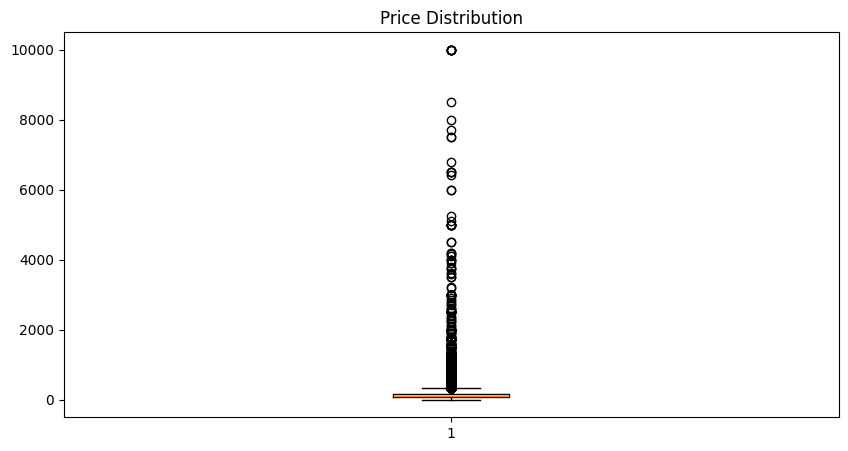

In [89]:
plt.figure(figsize=(10,5))
plt.boxplot(x=df['price'])
plt.title("Price Distribution")
plt.show()

Listing with price=0

In [90]:
print("Listings with price 0:")
print((df['price'] == 0).sum())

Listings with price 0:
11


In [91]:
df = df[df['price'] > 0]

Outlier Detection

In [92]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("IQR:",IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

IQR: 106.0
Lower Bound: -90.0
Upper Bound: 334.0


In [93]:
price_outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

print(len(price_outliers))

2972


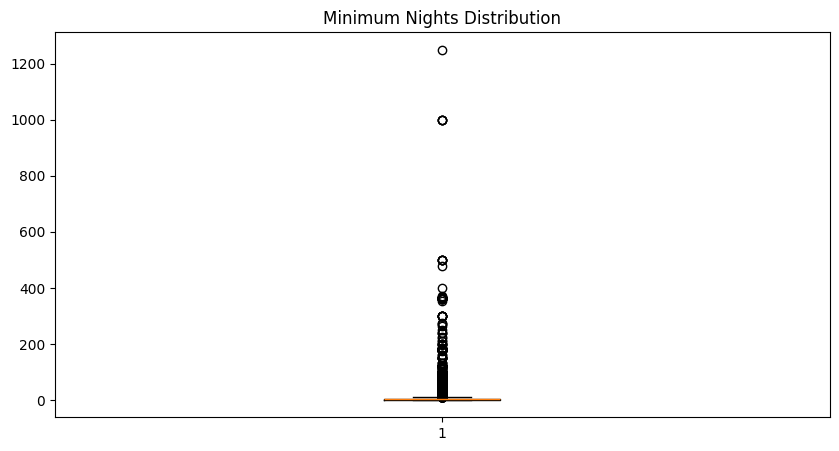

In [97]:
plt.figure(figsize=(10,5))
plt.boxplot(x=df['minimum_nights'])
plt.title("Minimum Nights Distribution")
plt.show()

In [95]:
df.shape

(48884, 16)

In [96]:
df.to_csv("nyc_airbnb_cleaned.csv", index=False)

print("\nData cleaning completed successfully!")
print("Cleaned file saved as: nyc_airbnb_cleaned.csv")


Data cleaning completed successfully!
Cleaned file saved as: nyc_airbnb_cleaned.csv


### Key Insights

• Missing values were identified in the name , host_name, last_review, and reviews_per_month columns and handled appropriately.

• No duplicate records were found in the dataset.

• Listings with invalid price values (price = 0) were identified and removed.

• Significant outliers were observed in the price and minimum_nights columns.

• Most Airbnb listings were priced within a moderate range, while a few luxury listings had exceptionally high prices.

• The majority of listings required a short minimum stay, whereas a small
number were intended for long-term rentals.

### Recommendations

• Implement regular validation checks to prevent invalid price entries.

• Improve data collection processes to minimize missing values.

• Monitor extreme price values to ensure they represent genuine listings.

• Periodically review listings with unusually high minimum-night requirements.

• Establish automated data quality checks to maintain dataset accuracy and consistency.

• Perform regular data cleaning and validation before conducting analysis or building predictive models.
